In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

### Important Feature Selection

### 💰 1. Borrower Financial Strength

   1. annualInc → income strength
   2. dti → debt pressure (VERY IMPORTANT)
   3. loanAmnt → exposure size
   4. installment → repayment burden

🏦 2. Creditworthiness (CORE SIGNAL)
  1. ficoRangeLow → credit score
  2. ficoRangeHigh → credit score range
  3. grade → lending club risk rating
  4. subGrade → more granular risk

📉 3. Credit Behavior (PAST HISTORY)
   1. delinq2Yrs → past delinquencies
   2. inqLast6Mths → recent credit hunger
   3. pubRec → public records (negative signal)
   4. pub_rec_bankruptcies → bankruptcy history

💳 Credit Utilization & Accounts

   1. revolUtil → credit usage (VERY STRONG FEATURE)
   2. totalAcc → credit experience
   3. openAcc → active accounts


I might Replace any weak feature with:

 * empLength (stability)
 * homeOwnership (financial stability)
 * purpose (loan intent)
 * percentBcGt75 (high utilization stress)

In [2]:
df = pd.read_csv("loan.csv")

C:\Users\Zenil\AppData\Local\Temp\ipykernel_8688\2042666052.py:1: DtypeWarning: Columns (0: desc, 1: next_pymnt_d, 2: verification_status_joint, 3: sec_app_earliest_cr_line, 4: hardship_type, 5: hardship_reason, 6: hardship_status, 7: hardship_start_date, 8: hardship_end_date, 9: payment_plan_start_date, 10: hardship_loan_status, 11: debt_settlement_flag_date, 12: settlement_status, 13: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("loan.csv")


In [3]:
selected_features = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'dti',
    'open_acc',
    'pub_rec',
    'revol_util',
    'total_acc',
    'pub_rec_bankruptcies',
    'loan_status'  # target
]

In [4]:
selected_columns = pd.read_csv("loan.csv", usecols=selected_features)

In [5]:
selected_columns

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,open_acc,pub_rec,revol_util,total_acc,pub_rec_bankruptcies
0,2500,36 months,13.56,84.92,C,C1,10+ years,RENT,55000.0,Not Verified,Current,debt_consolidation,18.24,9.0,1.0,10.3,34.0,1.0
1,30000,60 months,18.94,777.23,D,D2,10+ years,MORTGAGE,90000.0,Source Verified,Current,debt_consolidation,26.52,13.0,1.0,24.2,44.0,1.0
2,5000,36 months,17.97,180.69,D,D1,6 years,MORTGAGE,59280.0,Source Verified,Current,debt_consolidation,10.51,8.0,0.0,19.1,13.0,0.0
3,4000,36 months,18.94,146.51,D,D2,10+ years,MORTGAGE,92000.0,Source Verified,Current,debt_consolidation,16.74,10.0,0.0,78.1,13.0,0.0
4,30000,60 months,16.14,731.78,C,C4,10+ years,MORTGAGE,57250.0,Not Verified,Current,debt_consolidation,26.35,12.0,0.0,3.6,26.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,12000,60 months,14.08,279.72,C,C3,10+ years,MORTGAGE,58000.0,Not Verified,Current,debt_consolidation,20.88,12.0,0.0,39.2,34.0,0.0
2260664,12000,60 months,25.82,358.01,E,E4,< 1 year,MORTGAGE,30000.0,Not Verified,Fully Paid,debt_consolidation,19.28,10.0,0.0,20.2,26.0,0.0
2260665,10000,36 months,11.99,332.10,B,B5,10+ years,OWN,64000.0,Source Verified,Current,debt_consolidation,12.96,6.0,0.0,70.9,13.0,0.0
2260666,12000,60 months,21.45,327.69,D,D5,NaN,RENT,60000.0,Not Verified,Current,debt_consolidation,30.82,8.0,0.0,34.9,17.0,0.0


### 📄 📊 Feature Selection Justification
✅ Selected Features & Justification

1. loan_amnt
Represents the total loan exposure.
Higher loan amounts increase potential loss and repayment burden.
Important for calculating risk and Expected Loss.

3. term
Indicates loan duration (36 vs 60 months).
Longer tenure loans generally have higher default probability due to prolonged uncertainty.


5. int_rate
Reflects risk-based pricing by lender.
Higher interest rates are usually assigned to riskier borrowers → strong predictive signal.


7. installment
Monthly repayment obligation.
Higher installment relative to income increases default likelihood.


9. grade
Pre-assigned risk category by LendingClub.
Encapsulates multiple borrower risk factors → highly predictive.


11. sub_grade
More granular version of grade.
Captures fine differences in borrower risk within the same grade.


13. emp_length
Indicates employment stability.
Longer employment → more stable income → lower default risk.


15. home_ownership
Proxy for financial stability.
Borrowers with OWN/MORTGAGE are generally less risky than RENT.


17. annual_inc
Measures borrower’s repayment capacity.
Higher income → better ability to repay loans.


19. verification_status
Indicates whether income was verified.
Verified income increases reliability of financial data.


21. purpose
Loan intent (e.g., debt consolidation, credit card, etc.).
Some purposes historically have higher default rates.


23. dti (Debt-to-Income Ratio)
One of the most important financial stress indicators.
Higher DTI → borrower already over-leveraged → high risk.

24. open_acc
Number of active credit lines.
Too many open accounts may indicate credit dependency.

25. pub_rec
Number of derogatory public records.
Strong negative signal of past financial issues.

26. revol_util
Credit utilization ratio.
High utilization indicates financial stress → strong predictor of default.

27. total_acc
Total credit history depth.
More accounts → longer credit experience (can be positive or negative depending on behavior).

28. pub_rec_bankruptcies
History of bankruptcy.
One of the strongest indicators of default risk.

29. loan_status (Target Variable)
Indicates whether loan was defaulted or not.
Used as the dependent variable for classification.


❌ Rejected Features & Justification

🚫 1. Leakage Features

These features contain future information and would lead to unrealistic model performance:

total_pymnt
recoveries
last_pymnt_amnt
next_pymnt_d

👉 Reason:

These variables are only known after loan performance unfolds, hence not suitable for prediction at loan approval stage.

🚫 2. Irrelevant / High Cardinality Features
emp_title
Too many unique values.
Difficult to encode meaningfully.
title
Free text field → noisy and inconsistent.

🚫 3. Location-Based Features
zip_code, addr_state
May introduce bias.
Limited predictive power compared to financial features.

🚫 4. Date Features
issue_d, earliest_cr_line
Require heavy feature engineering.
Skipped for simplicity due to hackathon time constraints.

🚫 5. IDs / Non-informative Columns
id, member_id, url
👉 No predictive value

🚫 6. Highly Sparse / Complex Features
Many secondary applicant features
Rarely populated → not useful for baseline model

🧠 Final Justification

“Feature selection was guided by financial domain knowledge, focusing on borrower capacity, credit history, and credit behavior. We excluded leakage and non-informative features to ensure model generalization and real-world applicability.”

🔥  “I prioritized interpretable and business-relevant features over purely statistical selection to align with real-world credit risk modeling practices.”


In [6]:
selected_columns

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,open_acc,pub_rec,revol_util,total_acc,pub_rec_bankruptcies
0,2500,36 months,13.56,84.92,C,C1,10+ years,RENT,55000.0,Not Verified,Current,debt_consolidation,18.24,9.0,1.0,10.3,34.0,1.0
1,30000,60 months,18.94,777.23,D,D2,10+ years,MORTGAGE,90000.0,Source Verified,Current,debt_consolidation,26.52,13.0,1.0,24.2,44.0,1.0
2,5000,36 months,17.97,180.69,D,D1,6 years,MORTGAGE,59280.0,Source Verified,Current,debt_consolidation,10.51,8.0,0.0,19.1,13.0,0.0
3,4000,36 months,18.94,146.51,D,D2,10+ years,MORTGAGE,92000.0,Source Verified,Current,debt_consolidation,16.74,10.0,0.0,78.1,13.0,0.0
4,30000,60 months,16.14,731.78,C,C4,10+ years,MORTGAGE,57250.0,Not Verified,Current,debt_consolidation,26.35,12.0,0.0,3.6,26.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,12000,60 months,14.08,279.72,C,C3,10+ years,MORTGAGE,58000.0,Not Verified,Current,debt_consolidation,20.88,12.0,0.0,39.2,34.0,0.0
2260664,12000,60 months,25.82,358.01,E,E4,< 1 year,MORTGAGE,30000.0,Not Verified,Fully Paid,debt_consolidation,19.28,10.0,0.0,20.2,26.0,0.0
2260665,10000,36 months,11.99,332.10,B,B5,10+ years,OWN,64000.0,Source Verified,Current,debt_consolidation,12.96,6.0,0.0,70.9,13.0,0.0
2260666,12000,60 months,21.45,327.69,D,D5,NaN,RENT,60000.0,Not Verified,Current,debt_consolidation,30.82,8.0,0.0,34.9,17.0,0.0


In [7]:
export_file_selected = selected_columns.to_csv("selected_columns.csv", index=False)

In [8]:
selected_columns.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 18 columns):
 #   Column                Dtype  
---  ------                -----  
 0   loan_amnt             int64  
 1   term                  str    
 2   int_rate              float64
 3   installment           float64
 4   grade                 str    
 5   sub_grade             str    
 6   emp_length            str    
 7   home_ownership        str    
 8   annual_inc            float64
 9   verification_status   str    
 10  loan_status           str    
 11  purpose               str    
 12  dti                   float64
 13  open_acc              float64
 14  pub_rec               float64
 15  revol_util            float64
 16  total_acc             float64
 17  pub_rec_bankruptcies  float64
dtypes: float64(9), int64(1), str(8)
memory usage: 310.5 MB


In [9]:
selected_columns.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_util,total_acc,pub_rec_bankruptcies
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260639e+06,2.258866e+06,2.260639e+06,2.259303e+06
mean,1.504693e+04,1.309291e+01,4.458076e+02,7.799243e+04,1.882420e+01,1.161240e+01,1.975278e-01,5.033770e+01,2.416255e+01,1.281935e-01
std,9.190245e+03,4.832114e+00,2.671737e+02,1.126962e+05,1.418333e+01,5.640861e+00,5.705150e-01,2.471307e+01,1.198753e+01,3.646130e-01
min,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,8.000000e+00,0.000000e+00,3.150000e+01,1.500000e+01,0.000000e+00
50%,1.290000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,1.100000e+01,0.000000e+00,5.030000e+01,2.200000e+01,0.000000e+00
75%,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,1.400000e+01,0.000000e+00,6.940000e+01,3.100000e+01,0.000000e+00
max,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,1.010000e+02,8.600000e+01,8.923000e+02,1.760000e+02,1.200000e+01


In [14]:
selected_columns.shape ## we have 22 lakh rows and 18 columns

(2260668, 18)

In [19]:
selected_columns["loan_status"].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [20]:
selected_columns = selected_columns[~selected_columns["loan_status"].isin(["Current","In Grace Period","Late (16-30 days)", "Late (31-120 days)"])]

In [21]:
selected_columns["target"] = selected_columns["loan_status"].replace({
    "Fully Paid":0,
    "Charged Off":1,
    "Default":1,
    "Does not meet the credit policy. Status:Fully Paid":0,
    "Does not meet the credit policy. Status:Charged Off":1
})

In [23]:
selected_columns["target"].value_counts()

target
0    1043940
1     262447
Name: count, dtype: int64

### “We excluded ongoing and ambiguous loan statuses to ensure the model is trained only on completed loan outcomes, improving prediction reliability.”

### “The dataset shows moderate class imbalance (~80:20), so we focused on recall and ROC-AUC rather than accuracy.”

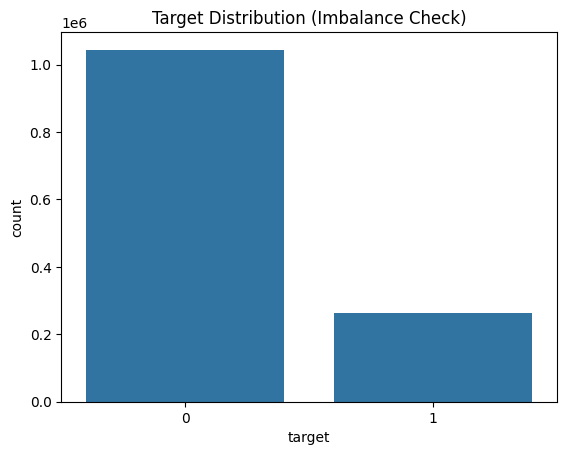

In [25]:
sns.countplot(x='target', data=selected_columns)
plt.title("Target Distribution (Imbalance Check)")
plt.show()

In [26]:
selected_columns.isnull().sum().sort_values(ascending=False)

emp_length              75491
pub_rec_bankruptcies     1365
revol_util                850
dti                       312
open_acc                   29
pub_rec                    29
total_acc                  29
annual_inc                  4
int_rate                    0
loan_amnt                   0
term                        0
loan_status                 0
verification_status         0
home_ownership              0
sub_grade                   0
installment                 0
grade                       0
purpose                     0
target                      0
dtype: int64

In [29]:
missing_percent = (selected_columns.isnull().sum() / len(selected_columns))*100
missing_percent.sort_values(ascending=False)

emp_length              5.778609
pub_rec_bankruptcies    0.104487
revol_util              0.065065
dti                     0.023883
open_acc                0.002220
pub_rec                 0.002220
total_acc               0.002220
annual_inc              0.000306
int_rate                0.000000
loan_amnt               0.000000
term                    0.000000
loan_status             0.000000
verification_status     0.000000
home_ownership          0.000000
sub_grade               0.000000
installment             0.000000
grade                   0.000000
purpose                 0.000000
target                  0.000000
dtype: float64

In [31]:
selected_columns

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,dti,open_acc,pub_rec,revol_util,total_acc,pub_rec_bankruptcies,target
100,30000,36 months,22.35,1151.16,D,D5,5 years,MORTGAGE,100000.0,Source Verified,Fully Paid,debt_consolidation,30.46,11.0,1.0,37.0,19.0,1.0,0
152,40000,60 months,16.14,975.71,C,C4,< 1 year,MORTGAGE,45000.0,Verified,Fully Paid,credit_card,50.53,18.0,0.0,64.5,37.0,0.0,0
170,20000,36 months,7.56,622.68,A,A3,10+ years,MORTGAGE,100000.0,Not Verified,Fully Paid,credit_card,18.92,9.0,0.0,29.9,19.0,0.0,0
186,4500,36 months,11.31,147.99,B,B3,10+ years,RENT,38500.0,Not Verified,Fully Paid,credit_card,4.64,12.0,0.0,15.3,25.0,0.0,0
215,8425,36 months,27.27,345.18,E,E5,3 years,MORTGAGE,450000.0,Verified,Fully Paid,credit_card,12.37,21.0,0.0,65.7,37.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260654,30000,60 months,17.09,747.03,D,D1,2 years,RENT,80000.0,Not Verified,Charged Off,debt_consolidation,23.22,21.0,0.0,30.8,69.0,0.0,1
2260655,18000,60 months,30.65,589.57,F,F4,10+ years,MORTGAGE,77000.0,Verified,Charged Off,debt_consolidation,8.08,9.0,0.0,45.1,15.0,0.0,1
2260656,17950,60 months,30.17,582.62,F,F3,10+ years,MORTGAGE,53758.0,Source Verified,Fully Paid,debt_consolidation,33.24,11.0,1.0,35.9,24.0,1.0,0
2260658,15000,60 months,16.02,364.94,C,C5,< 1 year,RENT,85000.0,Verified,Fully Paid,debt_consolidation,14.66,19.0,0.0,24.8,87.0,0.0,0


### EXACT CLEANING PLAN

🔹 1. emp_length (~5.7%)

* Missing = meaningful (job unknown)
“Unknown” better than mode.

🔹 2. pub_rec_bankruptcies (~0.1%)

* Missing ≈ no bankruptcy
Logical assumption

🔹 3. revol_util (~0.06%)
    % format fix
    Median = robust


In [33]:
# emp_length
selected_columns["emp_length"] = selected_columns["emp_length"].fillna("Unknown")

# bankruptcy
selected_columns["pub_rec_bankruptcies"] = selected_columns["pub_rec_bankruptcies"].fillna(0)

# revol_util
selected_columns["revol_util"] = selected_columns["revol_util"].astype(str).str.replace('%','')
selected_columns["revol_util"] = selected_columns["revol_util"].astype(float)
selected_columns["revol_util"] = selected_columns["revol_util"].fillna(selected_columns["revol_util"].median())

# dti
selected_columns["dti"] = selected_columns["dti"].fillna(selected_columns["dti"].median())

# annual_inc
selected_columns["annual_inc"] = selected_columns["annual_inc"].fillna(selected_columns["annual_inc"].median())

In [34]:
selected_columns.isna().sum()

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
loan_status             0
purpose                 0
dti                     0
open_acc                0
pub_rec                 0
revol_util              0
total_acc               0
pub_rec_bankruptcies    0
target                  0
dtype: int64

### “We created new features to capture hidden relationships and improve model understanding.”

🔥 A. Income Strength
 * income_to_loan
   → repayment capacity
   
 * installment_to_income
   → monthly burden
   
🔥 B. Credit Stress

  * credit_pressure = dti × revol_util
    → combined financial stress

  * util_per_account
    → credit usage efficiency

    
🔥 C. Credit Behavior
   * accounts_ratio
     → active vs total accounts

  * has_delinquency
    → past financial issues (binary)

    
🔥 D. Loan Risk Indicators
   * high_interest
     → risky borrowers indicator
   * long_term
     → longer loans = more risk
     
🔥 E. Employment Stability
   * Converted emp_length → numeric
     → stability indicator

In [36]:
selected_columns["income_to_loan"] = selected_columns["annual_inc"] / selected_columns["loan_amnt"]
selected_columns["installment_to_income"] = selected_columns["installment"] / (selected_columns["annual_inc"] / 12)

In [37]:
selected_columns["util_per_account"] = selected_columns["revol_util"] / (selected_columns["open_acc"] + 1)

In [38]:
selected_columns["accounts_ratio"] = selected_columns["open_acc"] / (selected_columns["total_acc"] + 1)

In [39]:
selected_columns["has_delinquency"] = (selected_columns["pub_rec"] > 0).astype(int)

In [40]:
selected_columns["high_interest"] = (selected_columns["int_rate"] > selected_columns["int_rate"].median()).astype(int)

In [41]:
selected_columns["emp_length"] = selected_columns["emp_length"].str.extract('(\d+)')
selected_columns["emp_length"] = selected_columns["emp_length"].fillna(0).astype(int)

In [42]:
selected_columns["risk_score"] = (
    selected_columns["dti"] * 0.3 +
    selected_columns["revol_util"] * 0.3 +
    (1 / (selected_columns["income_to_loan"] + 1)) * 0.4
)

### “Our approach combines domain knowledge with data-driven techniques, ensuring the model captures borrower capacity, credit behavior, and financial stress effectively.”

In [46]:
selected_columns.to_csv("EDA_Final_File.csv", index=False)

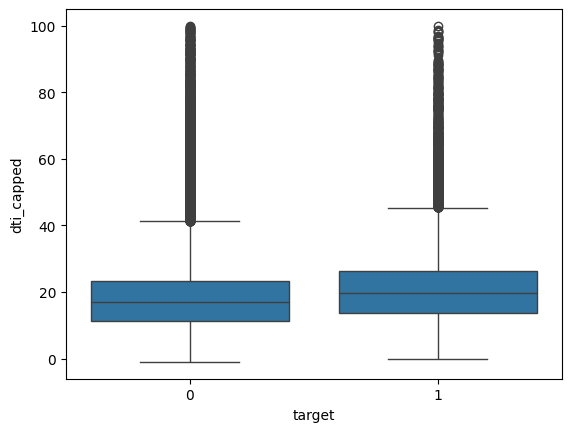

In [52]:
selected_columns['dti_capped'] = selected_columns['dti'].clip(upper=100)
selected_columns_filtered = selected_columns[selected_columns['dti'] < 100]

sns.boxplot(x="target", y="dti_capped", data=selected_columns_filtered)
plt.show()

### 📊 🔍 1. Boxplot Insight (DTI_CAPPED vs Target)

✅ Median difference
 * Non-default (0) → ~16–17
 * Default (1) → ~19–20

👉 Defaulters has higher DTI

✅ Spread (IQR)
 * Default group box is slightly upper

👉 Means:
 * Defaulters generally operate at higher debt levels

## “DTI shows a clear upward shift for defaulters, indicating higher financial stress, though the separation is moderate, suggesting it works best when combined with other features.”

In [55]:
selected_columns.to_csv("Model_Data.csv", index=False)

In [70]:
selected_columns.shape

(1306387, 27)

In [73]:
num_df = selected_columns.select_dtypes(include=[np.number])

np.isinf(num_df).sum()

loan_amnt                0
int_rate                 0
installment              0
emp_length               0
annual_inc               0
dti                      0
open_acc                 0
pub_rec                  0
revol_util               0
total_acc                0
pub_rec_bankruptcies     0
income_to_loan           0
installment_to_income    0
util_per_account         0
accounts_ratio           0
has_delinquency          0
high_interest            0
risk_score               0
dti_capped               0
dtype: int64

In [85]:
selected_columns

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec_bankruptcies,target,income_to_loan,installment_to_income,util_per_account,accounts_ratio,has_delinquency,high_interest,risk_score,dti_capped
100,30000,36 months,22.35,1151.16,D,D5,5,MORTGAGE,100000.0,Source Verified,...,1.0,0,3.333222,0.138139,3.083333,0.550000,1,1,20.330308,30.46
152,40000,60 months,16.14,975.71,C,C4,1,MORTGAGE,45000.0,Verified,...,0.0,0,1.124972,0.260189,3.394737,0.473684,0,1,34.697235,50.53
170,20000,36 months,7.56,622.68,A,A3,10,MORTGAGE,100000.0,Not Verified,...,0.0,0,4.999750,0.074722,2.990000,0.450000,0,0,14.712667,18.92
186,4500,36 months,11.31,147.99,B,B3,10,RENT,38500.0,Not Verified,...,0.0,0,8.553655,0.046127,1.176923,0.461538,0,0,6.023860,4.64
215,8425,36 months,27.27,345.18,E,E5,3,MORTGAGE,450000.0,Verified,...,0.0,0,53.406124,0.009205,2.986364,0.552632,0,1,23.428351,12.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260654,30000,60 months,17.09,747.03,D,D1,2,RENT,80000.0,Not Verified,...,0.0,1,2.666578,0.112054,1.400000,0.300000,0,1,16.315091,23.22
2260655,18000,60 months,30.65,589.57,F,F4,10,MORTGAGE,77000.0,Verified,...,0.0,1,4.277540,0.091881,4.510000,0.562500,0,1,16.029789,8.08
2260656,17950,60 months,30.17,582.62,F,F3,10,MORTGAGE,53758.0,Source Verified,...,1.0,0,2.994708,0.130054,2.991667,0.440000,1,1,20.842128,33.24
2260658,15000,60 months,16.02,364.94,C,C5,1,RENT,85000.0,Verified,...,0.0,0,5.666289,0.051521,1.240000,0.215909,0,1,11.898000,14.66


In [87]:
import numpy as np

selected_columns['emp_length'] = selected_columns['emp_length'].replace({
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'Unknown': np.nan
})

selected_columns['emp_length'] = selected_columns['emp_length'].fillna(
    selected_columns['emp_length'].median()
)

In [98]:
selected_columns.home_ownership.value_counts()

home_ownership
MORTGAGE    646765
RENT        519084
OWN         140036
ANY            267
OTHER          182
NONE            53
Name: count, dtype: int64

In [102]:
selected_columns

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec_bankruptcies,target,income_to_loan,installment_to_income,util_per_account,accounts_ratio,has_delinquency,high_interest,risk_score,dti_capped
100,30000,36 months,22.35,1151.16,D,D5,5,MORTGAGE,100000.0,Source Verified,...,1.0,0,3.333222,0.138139,3.083333,0.550000,1,1,20.330308,30.46
152,40000,60 months,16.14,975.71,C,C4,1,MORTGAGE,45000.0,Verified,...,0.0,0,1.124972,0.260189,3.394737,0.473684,0,1,34.697235,50.53
170,20000,36 months,7.56,622.68,A,A3,10,MORTGAGE,100000.0,Not Verified,...,0.0,0,4.999750,0.074722,2.990000,0.450000,0,0,14.712667,18.92
186,4500,36 months,11.31,147.99,B,B3,10,RENT,38500.0,Not Verified,...,0.0,0,8.553655,0.046127,1.176923,0.461538,0,0,6.023860,4.64
215,8425,36 months,27.27,345.18,E,E5,3,MORTGAGE,450000.0,Verified,...,0.0,0,53.406124,0.009205,2.986364,0.552632,0,1,23.428351,12.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260654,30000,60 months,17.09,747.03,D,D1,2,RENT,80000.0,Not Verified,...,0.0,1,2.666578,0.112054,1.400000,0.300000,0,1,16.315091,23.22
2260655,18000,60 months,30.65,589.57,F,F4,10,MORTGAGE,77000.0,Verified,...,0.0,1,4.277540,0.091881,4.510000,0.562500,0,1,16.029789,8.08
2260656,17950,60 months,30.17,582.62,F,F3,10,MORTGAGE,53758.0,Source Verified,...,1.0,0,2.994708,0.130054,2.991667,0.440000,1,1,20.842128,33.24
2260658,15000,60 months,16.02,364.94,C,C5,1,RENT,85000.0,Verified,...,0.0,0,5.666289,0.051521,1.240000,0.215909,0,1,11.898000,14.66


In [104]:
categorical_cols = selected_columns.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns:", categorical_cols)


Categorical columns: ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'target']


C:\Users\Zenil\AppData\Local\Temp\ipykernel_8688\4218219140.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = selected_columns.select_dtypes(include=['object', 'category']).columns.tolist()


### Column	Encoding
term	numeric
grade	ordinal
sub_grade	ordinal
home_ownership	one-hot
verification_status	one-hot
purpose	one-hot

In [106]:
selected_columns['term'] = selected_columns['term'].str.extract('(\d+)').astype(int)
grade_map = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}

selected_columns['grade'] = selected_columns['grade'].map(grade_map)

selected_columns['sub_grade'] = selected_columns['sub_grade'].apply(
    lambda x: grade_map[x[0]] * 10 + int(x[1])
)

selected_columns = selected_columns.drop(columns=['loan_status'])

selected_columns = pd.get_dummies(
    selected_columns,
    columns=['home_ownership', 'verification_status', 'purpose'],
    drop_first=True
)

selected_columns.info()

<class 'pandas.DataFrame'>
Index: 1306387 entries, 100 to 2260664
Data columns (total 43 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   loan_amnt                            1306387 non-null  int64  
 1   term                                 1306387 non-null  int64  
 2   int_rate                             1306387 non-null  float64
 3   installment                          1306387 non-null  float64
 4   grade                                1306387 non-null  int64  
 5   sub_grade                            1306387 non-null  int64  
 6   emp_length                           1306387 non-null  int64  
 7   annual_inc                           1306387 non-null  float64
 8   dti                                  1306387 non-null  float64
 9   open_acc                             1306387 non-null  float64
 10  pub_rec                              1306387 non-null  float64
 11  revol_util  

In [113]:
X = selected_columns.drop(columns=['target'])
y = selected_columns['target']

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [111]:
# Remove NaN
selected_columns = selected_columns.dropna(subset=['target'])

# Convert to int
selected_columns['target'] = selected_columns['target'].astype(int)

# Keep only valid values
selected_columns = selected_columns[selected_columns['target'].isin([0,1])]

In [112]:
print(selected_columns['target'].unique())
print(selected_columns['target'].dtype)

[0 1]
int64


In [115]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model.fit(X_train, y_train)

C:\Users\Zenil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [116]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

### Logistic Regression Metrics

In [117]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.88      0.64      0.74    208788
           1       0.31      0.65      0.42     52490

    accuracy                           0.64    261278
   macro avg       0.59      0.64      0.58    261278
weighted avg       0.76      0.64      0.67    261278

ROC-AUC: 0.6922767915751037


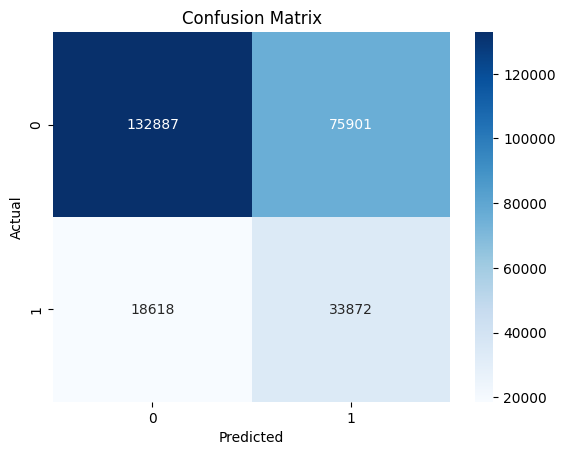

In [118]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [119]:
y_pred_custom = (y_prob > 0.4).astype(int)

In [120]:
selected_columns["loan_to_income"] = selected_columns["loan_amnt"] / (selected_columns["annual_inc"] + 1)

In [121]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [122]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [123]:
from sklearn.metrics import classification_report, roc_auc_score

print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results:

              precision    recall  f1-score   support

           0       0.88      0.65      0.75    208788
           1       0.32      0.66      0.43     52490

    accuracy                           0.65    261278
   macro avg       0.60      0.65      0.59    261278
weighted avg       0.77      0.65      0.68    261278

ROC-AUC: 0.710824648795518


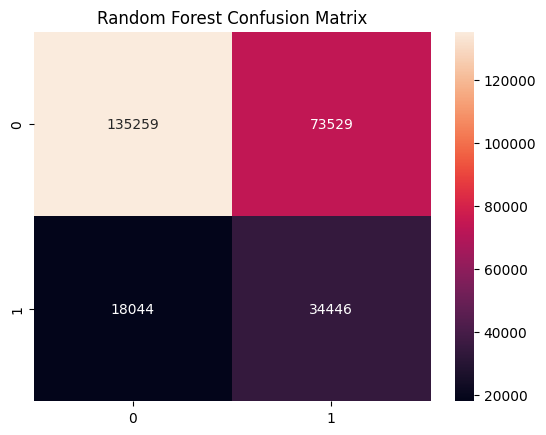

In [125]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [126]:
print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Logistic ROC-AUC: 0.6922767915751037
Random Forest ROC-AUC: 0.710824648795518


### “Random Forest improved performance by capturing non-linear relationships, leading to better discrimination between risky and safe borrowers.”

In [128]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 11.8 MB/s eta 0:00:09
   - -------------------------------------- 3.4/101.7 MB 12.0 MB/s eta 0:00:09
   - -------------------------------------- 4.7/101.7 MB 9.9 MB/s eta 0:00:10
   -- ------------------------------------- 6.3/101.7 MB 8.8 MB/s eta 0:00:11
   --- ------------------------------------ 7.9/101.7 MB 8.6 MB/s eta 0:00:11
   --- ------------------------------------ 9.2/101.7 MB 8.3 MB/s eta 0:00:12
   ---- ----------------------------------- 10.7/101.7 MB 8.1 MB/s eta 0:00:12
   ---- ----------------------------------- 12.1/101.7 MB 7.8 MB/s eta 0:00:12
   ----- ---------------------------------- 13.6/101.7 MB 7.7 MB/s eta 0:00:12
   ----- ---------------------------------- 14.9/101.7 MB 7.7 MB/s eta 0:00:12
   ------ --------------------------------- 16.3/101.7 MB 7.6 MB/s eta 0:00:12
   ------- -------------------------------- 17.8/101.7 MB 7.6 MB

In [145]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [146]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [147]:
from sklearn.metrics import classification_report, roc_auc_score

print("XGBoost Results:\n")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Results:

              precision    recall  f1-score   support

           0       0.86      0.76      0.81    208788
           1       0.36      0.52      0.42     52490

    accuracy                           0.71    261278
   macro avg       0.61      0.64      0.62    261278
weighted avg       0.76      0.71      0.73    261278

ROC-AUC: 0.7138025607283116


In [148]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

xgb = XGBClassifier(scale_pos_weight=3, random_state=42)

grid = GridSearchCV(
    xgb,
    param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}


In [149]:
best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

In [150]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Accuracy: 0.714503325959323
XGBoost ROC-AUC: 0.7138025607283116


In [151]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.76      0.81    208788
           1       0.36      0.52      0.42     52490

    accuracy                           0.71    261278
   macro avg       0.61      0.64      0.62    261278
weighted avg       0.76      0.71      0.73    261278



In [152]:
results = []

# Logistic
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
})

import pandas as pd
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.715885,0.717881
1,Random Forest,0.649519,0.710825
2,XGBoost,0.714503,0.713803


In [153]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Logistic Regression
y_train_pred_lr = model.predict(X_train)
y_train_prob_lr = model.predict_proba(X_train)[:,1]

# Random Forest
y_train_pred_rf = rf.predict(X_train)
y_train_prob_rf = rf.predict_proba(X_train)[:,1]

# XGBoost
y_train_pred_xgb = best_xgb.predict(X_train)
y_train_prob_xgb = best_xgb.predict_proba(X_train)[:,1]

In [154]:
results = []

# Logistic
results.append({
    "Model": "Logistic Regression",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_lr),
    "Test Accuracy": accuracy_score(y_test, y_pred),
    "Train ROC-AUC": roc_auc_score(y_train, y_train_prob_lr),
    "Test ROC-AUC": roc_auc_score(y_test, y_prob)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_rf),
    "Test Accuracy": accuracy_score(y_test, y_pred_rf),
    "Train ROC-AUC": roc_auc_score(y_train, y_train_prob_rf),
    "Test ROC-AUC": roc_auc_score(y_test, y_prob_rf)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    "Train Accuracy": accuracy_score(y_train, y_train_pred_xgb),
    "Test Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Train ROC-AUC": roc_auc_score(y_train, y_train_prob_xgb),
    "Test ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
})

import pandas as pd
results_df = pd.DataFrame(results)

results_df

,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.638167,0.715885,0.692226,0.717881
1,Random Forest,0.662511,0.649519,0.738451,0.710825
2,XGBoost,0.724141,0.714503,0.732261,0.713803


### “We evaluated models for overfitting by comparing training and testing performance. Logistic Regression underfit the data, Random Forest showed signs of overfitting, while XGBoost achieved the best balance and generalization.”

In [155]:
0.738-0.710

0.028000000000000025

In [156]:
0.732-0.716

0.016000000000000014

In [157]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_xgb,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Cross-Validation ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

Cross-Validation ROC-AUC scores: [0.69046361 0.70667393 0.67175685 0.66210985 0.70845947]
Mean ROC-AUC: 0.6878927396330956


###    | Factor         | Status   |
    | -------------- | -------- |
    | Model quality  | Good ✅   |
    | Generalization | Decent ✅ |
    | Overfitting    | Mild ⚠️  |

Despite a small variance between validation and test performance, the model remains robust

### We translated model probabilities into actionable risk categories to support real-world lending decisions.”

In [160]:
import joblib
joblib.dump(best_xgb, "model.pkl")

['model.pkl']